In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime
import os

import tkinter as tk
from tkinter import filedialog as fd
from docxtpl import DocxTemplate
import docxtpl
from docx.shared import Mm
import requests

import rasterio
from rasterio.plot import show
from matplotlib.patches import Patch

import collections
import qrcode
import gspread
from oauth2client.service_account import ServiceAccountCredentials

import sys
sys.path.append('..')

from sqlalchemy import create_engine, text

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import POSTGRES_UTEA

USER_DB = POSTGRES_UTEA['USER']
PASS_DB = POSTGRES_UTEA['PASSWORD']
HOST_DB = POSTGRES_UTEA['HOST']
PORT_DB = POSTGRES_UTEA['PORT']
NAME_DB = POSTGRES_UTEA['DATABASE']

In [3]:
# funcion que retorna el encale para conectar a base de datos
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

# obtener todo el catastro de la base datos
def get_catastro():
    engine = get_engine()
    try:
        query = """
            SELECT * FROM catastro_iag.catastro
        """
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ Error en get_catastro(): {e}")
        return gpd.GeoDataFrame()
    return None

def inserct_registro_y_get_id(fecha, codigo, nombre, tipo):
    engine = get_engine()
    # Definimos la consulta con la cláusula RETURNING
    query = text("""
        INSERT INTO catastro_iag.cite (fecha, codigo, nombre, tipo)
        VALUES (:fecha, :codigo, :nombre, :tipo)
        RETURNING nro; 
    """)
    try:
        with engine.connect() as conn:
            # Ejecutamos y obtenemos el primer resultado (el ID generado)
            result = conn.execute(query, {
                "fecha": fecha,
                "codigo": codigo,
                "nombre": nombre,
                "tipo": tipo
            })
            # Confirmamos los cambios (necesario en versiones recientes de SQLAlchemy)
            conn.commit()
            # .scalar() extrae el valor único de la primera columna de la primera fila
            nuevo_id = result.scalar()
            return nuevo_id
    except Exception as e:
        print(f"❌ Error al registra nuevo CITE: {e}")
        return None

def get_qr(grupo, cod_delegado, nom_delegado):
    texto = '''
--UTEA--
--DATOS CATASTRALES--
Codigo informe: {cod_inf}
Fecha de emición: {fecha}
Nombre de Canero: {canero}
Codigo Canero: {cod_ca}
Tipo de informe: {tipo}'''\
    .format(
    cod_inf=str(grupo.cite) + '-' + grupo.fecha[6:], 
    fecha=grupo.fecha, 
    canero=cod_delegado,
    cod_ca=nom_delegado,
    tipo='Informe para Banco')
    # Generar el código QR
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=10,
        border=4,
    )
    qr.add_data(texto)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    filename_qr = 'qr_' + str(cod_delegado) + '_' + grupo.fecha.replace('/', '-')
    path_qr = PATH_COMPLETO + '/planos/' + filename_qr + '.png'
    #Guardar el código QR en un archivo
    img.save(path_qr)
    return path_qr

In [4]:
# ruta de _DATOS_PYTHON
PATH_COMPLETO = os.path.join(RUTA_UNIDAD_ONE_DRIVE, RUTA_LOCAL_ONE_DRIVE)
# ruta de grupos de trabajo de la camapaña actual
PATH_GRUPOS_TRABAJO = RUTA_UNIDAD_ONE_DRIVE + r'\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - AVANCE COSECHA\2026\DATA\GRUPO_TRABAJO.xlsx'
# cargar en dataframe los grupos de trabajo
DF_GRUPOS_TRABAJO = pd.read_excel(PATH_GRUPOS_TRABAJO, sheet_name='2026')

## Leer catastro

In [5]:
# obtener todo catastro de base de datos
dgf_catastro = get_catastro()
# aplicar filtro correspondite para halidar lotes de la presente campaña
dgf_catastro = dgf_catastro[
    (dgf_catastro['unidad_03'] != 0) & 
    (dgf_catastro['cultivo'] == 'canha') & 
    (dgf_catastro['zafra'] == 2026)]
# verificar area total de catastro
area_total = dgf_catastro['area'].sum()
print(f'✅ Area: {round(area_total, 2)} ha')

✅ Area: 59343.23 ha


## Leer codigos de grupo

In [7]:
# codigo de grupo para procesa
codigo_trabajo = 403

In [8]:
# obtiene el grupo de trabajo
grupo_trabajo = DF_GRUPOS_TRABAJO[DF_GRUPOS_TRABAJO['GRUPO TRABAJO']==codigo_trabajo].copy()
# validad si existe un grupo con el codigo determinado
if len(grupo_trabajo) == 0:
    print(f'❌ No existe un grupo con codigo: {codigo_trabajo}')
grupo_trabajo['NOMBRE CAÑERO'] = grupo_trabajo['NOMBRE CAÑERO'].str.strip()
print(f'✅ Grupo:')
grupo_trabajo

✅ Grupo:


,CODIGO CAÑERO,NOMBRE CAÑERO,GRUPO TRABAJO,INS,DELEGADO
993,1447,CABRERA CAROLINA CRONENBOLD DE,403,50,NaN
994,2641,CRONENBOLD AGUILERA ROBERTO,403,50,DELEGADO
995,6638,CABRERA LOMBARDI LEANDRO JAVIER,403,50,NaN
996,41952,YOSHIDA SCHWENK HITOSHI,403,50,NaN
997,42021,ZAMBRANA MICHAELIS JORGE GERD,403,50,NaN
998,42226,URENDA LANDIVAR ANDRES,403,50,NaN
999,42441,ORTIZ BANZER JUAN CARLOS,403,50,NaN
1000,42578,AÑEZ RIVERO CARLOS ARTURO,403,50,NaN


In [9]:
# selecciona el miembro delegado del grupo
delegado = grupo_trabajo[grupo_trabajo['DELEGADO'] == 'DELEGADO']
# valida si solo existe un solo delegado
if (len(delegado) != 1):
    print('❌ Error al seleccionar delegado')
# extrae el codigo y nombre del delegado de grupo
codigo_delegado = delegado.iloc[0]['CODIGO CAÑERO']
nombre_delegado = delegado.iloc[0]['NOMBRE CAÑERO']
print(f'✅ Delegado: {codigo_delegado} / {nombre_delegado}')

✅ Delegado: 2641 / CRONENBOLD AGUILERA ROBERTO


In [10]:
lista_codigos_caneros = list(grupo_trabajo['CODIGO CAÑERO'])
print(f'✅ Lista de codigos: {lista_codigos_caneros}')

✅ Lista de codigos: [1447, 2641, 6638, 41952, 42021, 42226, 42441, 42578]


In [11]:
obj_grupo = []
for i in lista_codigos_caneros:
    cod_ca = grupo_trabajo[grupo_trabajo['CODIGO CAÑERO'] == i].iloc[0]['CODIGO CAÑERO']
    nom_ca = grupo_trabajo[grupo_trabajo['CODIGO CAÑERO'] == i].iloc[0]['NOMBRE CAÑERO']
    dict_ca = { 'cod_ca' : cod_ca, 'nom_ca' : nom_ca }
    obj_grupo.append(collections.namedtuple("canhero", dict_ca.keys())(*dict_ca.values()))
print(f'✅ Objeto de cañeros de grupo:')
obj_grupo

✅ Objeto de cañeros de grupo:


[canhero(cod_ca=1447, nom_ca='CABRERA CAROLINA CRONENBOLD DE'),
 canhero(cod_ca=2641, nom_ca='CRONENBOLD AGUILERA ROBERTO'),
 canhero(cod_ca=6638, nom_ca='CABRERA LOMBARDI LEANDRO JAVIER'),
 canhero(cod_ca=41952, nom_ca='YOSHIDA SCHWENK HITOSHI'),
 canhero(cod_ca=42021, nom_ca='ZAMBRANA MICHAELIS JORGE GERD'),
 canhero(cod_ca=42226, nom_ca='URENDA LANDIVAR ANDRES'),
 canhero(cod_ca=42441, nom_ca='ORTIZ BANZER JUAN CARLOS'),
 canhero(cod_ca=42578, nom_ca='AÑEZ RIVERO CARLOS ARTURO')]

In [12]:
# get fecha actual
fecha = datetime.now().strftime("%Y-%m-%d")
# registrar y obtener cite para informe
cite = inserct_registro_y_get_id(fecha, int(codigo_delegado), nombre_delegado, 'INBA')
print(f'✅ CITE creado: {cite}')

✅ CITE creado: 1272


In [13]:
# get fecha en formato dd/mm/aaaa
fecha = datetime.now().strftime("%d/%m/%Y")
# crear diccionario con datos de grupo de trabajo
datos_grupo = { 'fecha' : fecha, 'cite': cite, 'ca' : obj_grupo }
# crea objeto de datos de grupo de trabajo
datos_grupo = collections.namedtuple("insp", datos_grupo.keys())(*datos_grupo.values())
print(f'✅ Objeto grupo de trabajo:')
datos_grupo

✅ Objeto grupo de trabajo:


insp(fecha='27/08/2026', cite=1272, ca=[canhero(cod_ca=1447, nom_ca='CABRERA CAROLINA CRONENBOLD DE'), canhero(cod_ca=2641, nom_ca='CRONENBOLD AGUILERA ROBERTO'), canhero(cod_ca=6638, nom_ca='CABRERA LOMBARDI LEANDRO JAVIER'), canhero(cod_ca=41952, nom_ca='YOSHIDA SCHWENK HITOSHI'), canhero(cod_ca=42021, nom_ca='ZAMBRANA MICHAELIS JORGE GERD'), canhero(cod_ca=42226, nom_ca='URENDA LANDIVAR ANDRES'), canhero(cod_ca=42441, nom_ca='ORTIZ BANZER JUAN CARLOS'), canhero(cod_ca=42578, nom_ca='AÑEZ RIVERO CARLOS ARTURO')])

In [14]:
# get qr con info del informe
path_qr = get_qr(datos_grupo, codigo_delegado, nombre_delegado)
print(f'✅ Ruta de QR de informe:')
path_qr

✅ Ruta de QR de informe:


'G:\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON/planos/qr_2641_27-08-2026.png'

In [15]:
catastro_de_grupo = dgf_catastro[dgf_catastro['unidad_03'].isin(lista_codigos_caneros)]

In [16]:
lista_codigos_propiedad = list(set(catastro_de_grupo['unidad_01']))
lista_codigos_propiedad = [int(codigo_prop) for codigo_prop in lista_codigos_propiedad]
lista_codigos_propiedad

[1447, 2183, 1520, 1521, 220, 2013, 1758, 63]

In [115]:
#lista_codigos_propiedad = [55]

In [17]:
total_hoja = 0
total_soca = 0
total_renov = 0
total_produc = 0
total_cultivado = 0
props_obj = []

for i in lista_codigos_propiedad:
    propiedad = catastro_de_grupo[catastro_de_grupo['unidad_01'] == i]
    
    cod_prop = int(propiedad.iloc[0]['unidad_01'])
    nom_prop = propiedad.iloc[0]['unidad_02'].replace('_', ' ').split('--')[0]
    
    hoja = propiedad[propiedad['soca'] == 0]['area'].sum()
    soca = propiedad[(propiedad['soca'] > 0) & (propiedad['cultivo']!='renovacion')]['area'].sum()
    renov = propiedad[propiedad['cultivo']=='renovacion']['area'].sum()
    
    produc = hoja + soca
    cultivado = hoja + soca + renov
    
    total_hoja += hoja
    total_soca += soca
    total_renov += renov
    total_produc += produc
    total_cultivado += cultivado
    
    # seleccionar las columnas
    prop_data = propiedad[['unidad_05', 'area', 'variedad', 'fs', 'soca', 'cultivo']].copy()
    # cambiar nombre de comlumnas
    prop_table = prop_data.rename(columns={'unidad_05':'lote', 'area':'area', 'variedad':'variedad', 'fs':'fs', 'soca':'corte', 'cultivo':'estado'})
    # truncar a dos decimales
    prop_table['area'] = prop_table['area'].round(decimals=2)
    # formato de fecha
    prop_table['fs'] = pd.to_datetime(prop_table['fs']).dt.strftime('%d/%m/%Y')
    
    lista_lotes = []
    for i in range(len(prop_table)):
        lote = prop_table.iloc[i].to_dict()
        if(lote['estado'] == 'renovacion'):
            lote['fs'] = ''
            lote['corte'] = ''
        lote = collections.namedtuple("lote", lote.keys())(*lote.values())
        lista_lotes.append(lote)
    
    propiedad_dict = { 
        'cod_prop' : cod_prop,
        'nom_prop' : nom_prop,
        'hoja' : hoja, 
        'soca' : soca, 
        'renov' : renov,
        'produc' : produc,
        'cultivado' : cultivado,
        'lotes' : lista_lotes}
    props_obj.append(collections.namedtuple("propiedad", propiedad_dict.keys())(*propiedad_dict.values()))

In [18]:
totales = { 
    't_hoja': total_hoja,
    't_soca' : total_soca,
    't_renov' : total_renov,
    't_produc': total_produc,
    't_cultivado' : total_cultivado}

In [19]:
totales

{'t_hoja': 81.19631713841035,
 't_soca': 484.9200942142153,
 't_renov': 0.0,
 't_produc': 566.1164113526256,
 't_cultivado': 566.1164113526256}

In [20]:
total = collections.namedtuple("total", totales.keys())(*totales.values())

In [21]:
def generar_plano_pulv(shp_prop, path_tif):
    # Cargar la imagen TIFF con rasterio
    with rasterio.open(path_tif) as src:
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]  # Límites geoespaciales
        img = src.read([1, 2, 3])  # Leer las bandas RGB
    # Crear el plano
    fig, ax = plt.subplots(figsize=(15, 15))
    # Mostrar la imagen de fondo (TIFF) con coordenadas georreferenciadas
    show(img, transform=src.transform, ax=ax)
    #facecolor=(R, G, B, Alpha)
    shp_prop.plot(ax=ax, edgecolor='red', facecolor=(0, 0, 0, 0), linewidth=1)
    # Agregar etiquetas con lote mas area
    for idx, row in shp_prop.iterrows():
        if row.geom is not None:
            label = f"{row['unidad_05']}\n{round(row['area'], 2)} ha"
            centroid = row.geom.representative_point()  # Mejor que .centroid en algunos casos
            ax.text(centroid.x, centroid.y, label, fontsize=7, ha='center', color='black', weight=1000,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.2, pad=0))
    # Configurar título
    nom_prop = shp_prop["unidad_02"].iloc[0]
    cod_prop = shp_prop["unidad_01"].iloc[0]
    ax.set_title(str(int(cod_prop)) + ' / ' + nom_prop, fontsize=14)

    # 🔍 **Ajustar los límites del mapa para hacer zoom en la propiedad**
    bounds = shp_prop.total_bounds  # [xmin, ymin, xmax, ymax]
    ax.set_xlim([bounds[0] - 400, bounds[2] + 400])
    ax.set_ylim([bounds[1] - 400, bounds[3] + 400])
    # 🔹 **Agregar Leyenda**
    legend_elements = [
        #facecolor=(R, G, B, Alpha)
        Patch(facecolor=(0, 0, 0, 0), edgecolor='red', label='Lotes Propiedad')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='black')

    path_output = RUTA_UNIDAD_ONE_DRIVE + r"\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_" + str(int(cod_prop)) + "_" + nom_prop + '.jpg'
    print(path_output)
    # Guardar plano
    fig.savefig(path_output, dpi = 300, bbox_inches='tight')
    return path_output
    # Mostrar el mapa
    #plt.show()

G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_1447_LA SUIZA--CRONEMBOLD YOSHIDA.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_2183_NARANJAL--CRONEMBOLD.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_1520_VILLA COPACABANA--CRONENBOLD.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_1521_DON LUIS & TAJIBO.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_220_SANTA BARBARA--CRONENBOLD ROBERTO.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_2013_LA ASUNTA--CRONEMBOLD.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_1758_LA SUIZA II--CRONEMBOLD YOSHIDA.jpg
G:\\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_63_SAN MARIANITO--CRONEMBOLD AGUILERA.jpg


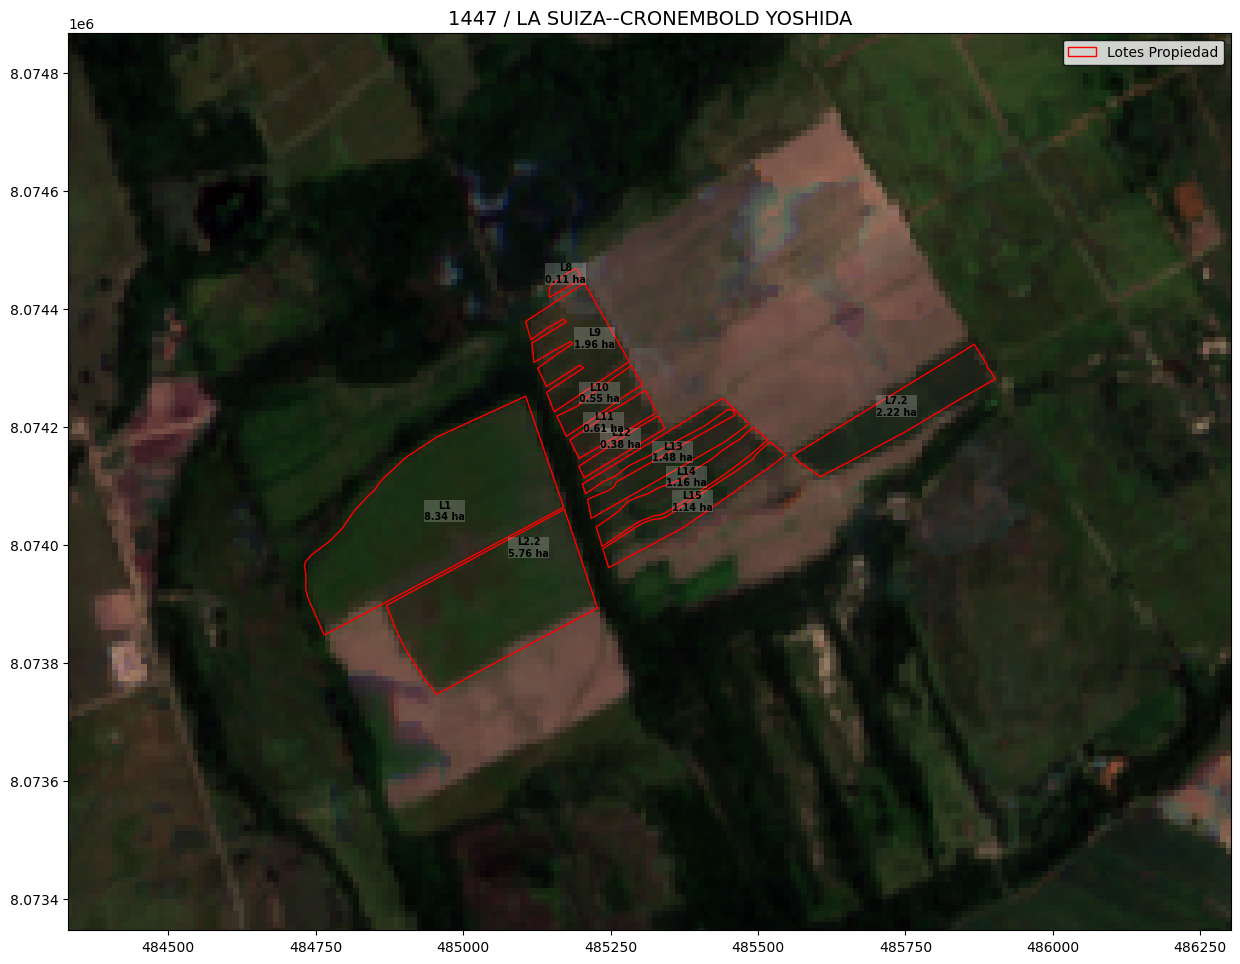

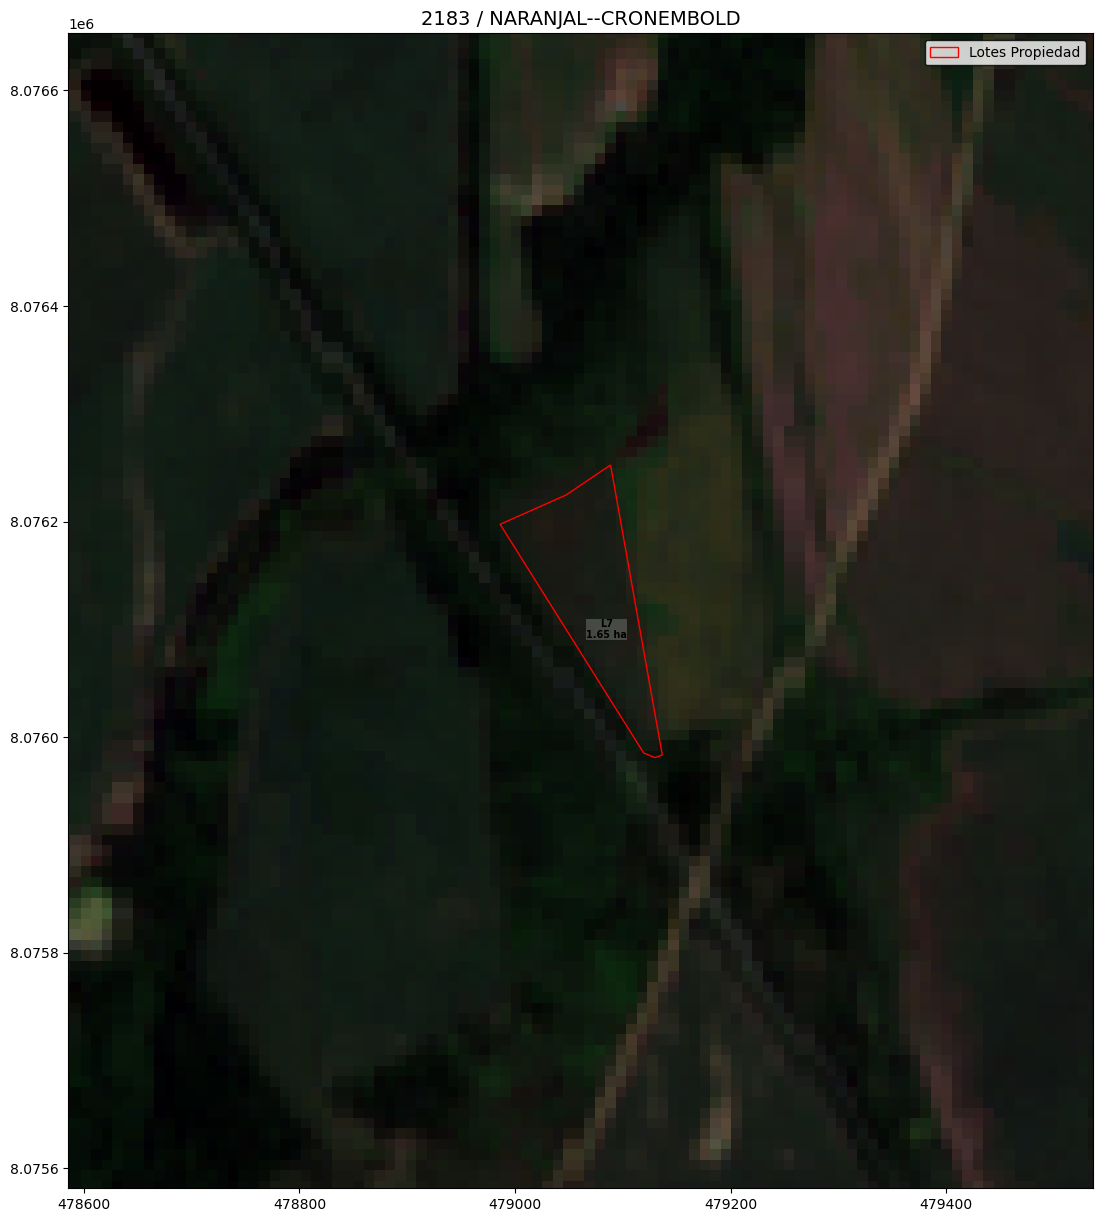

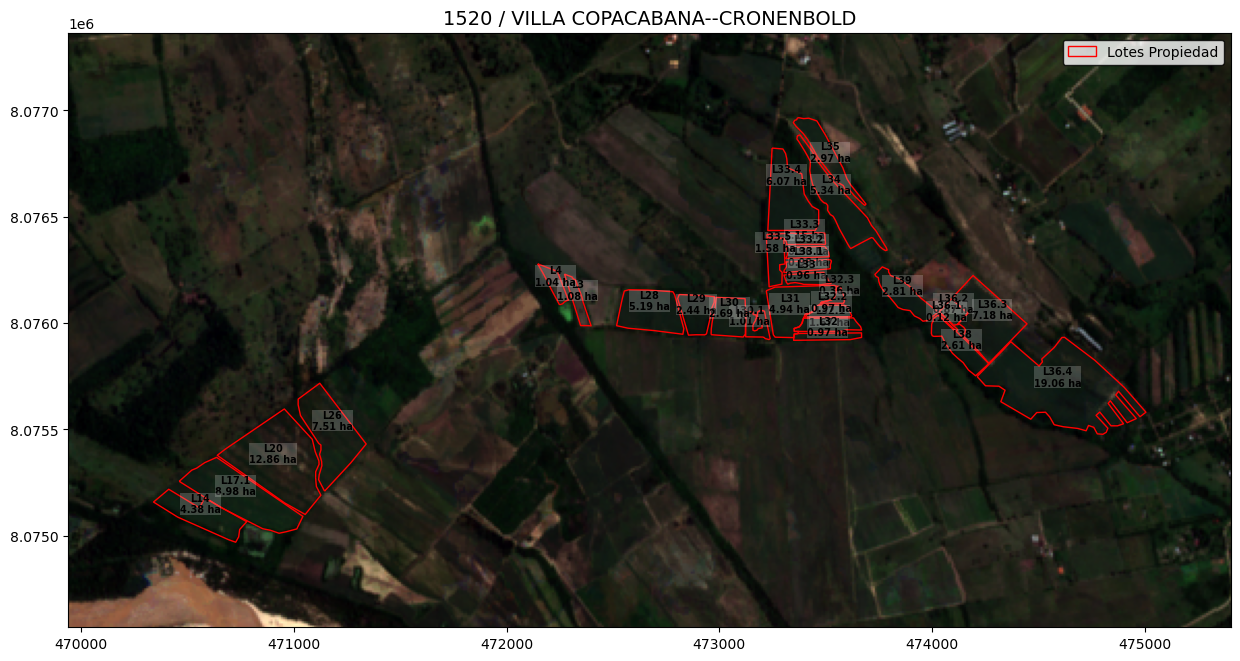

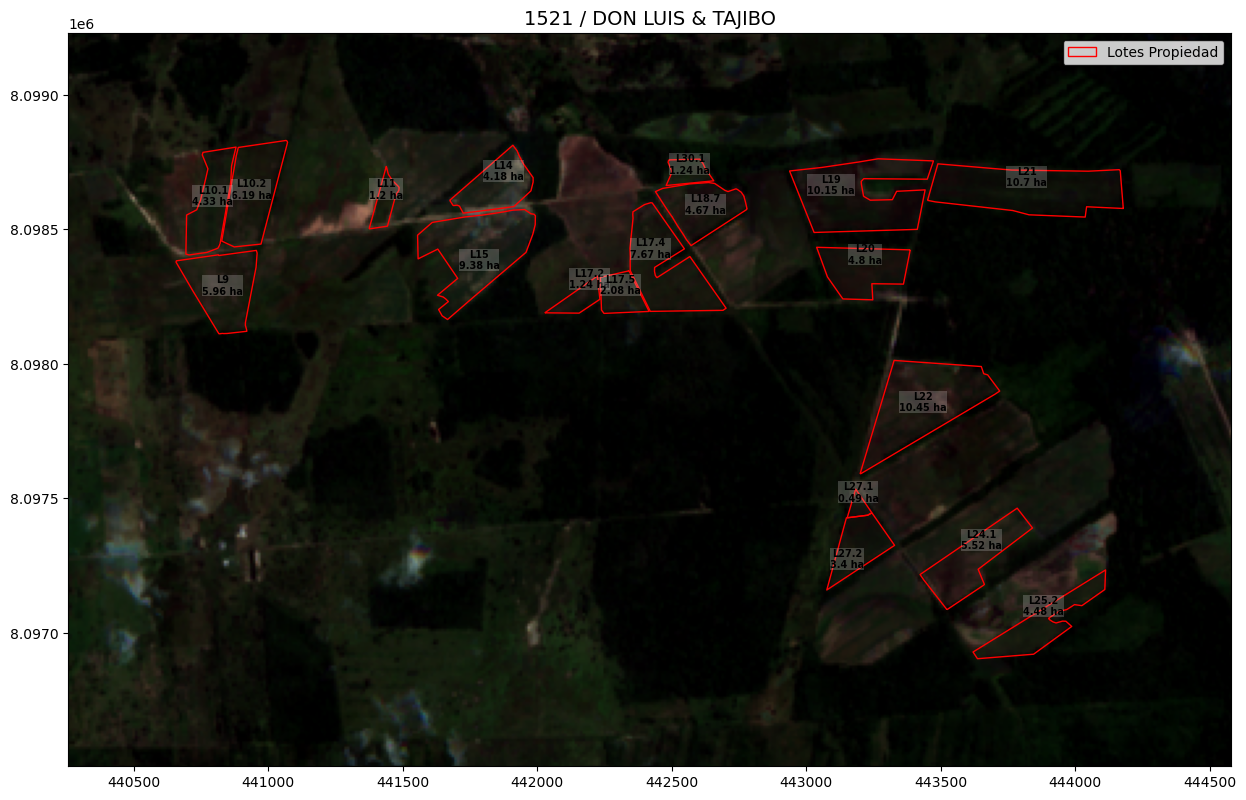

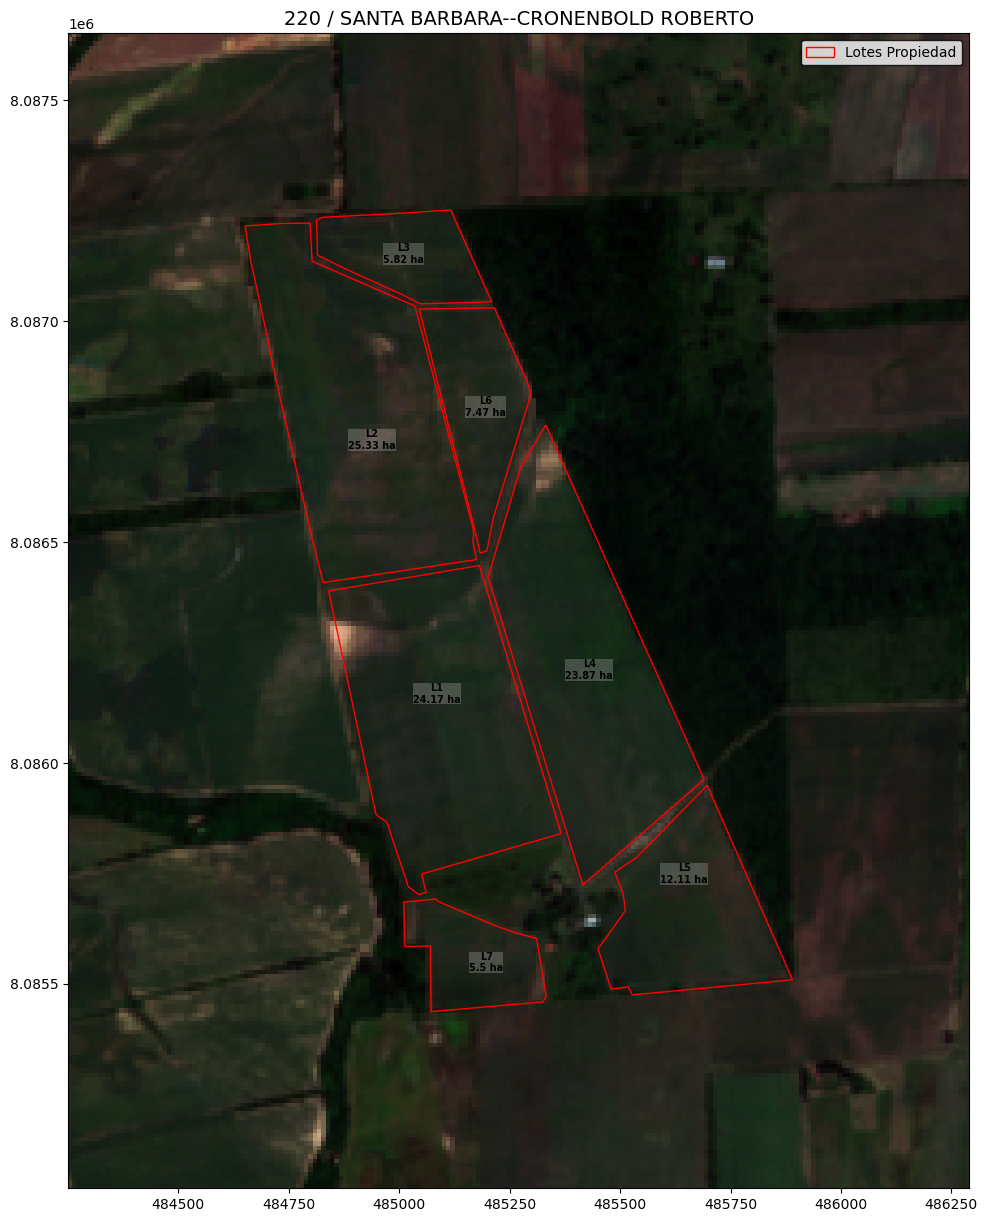

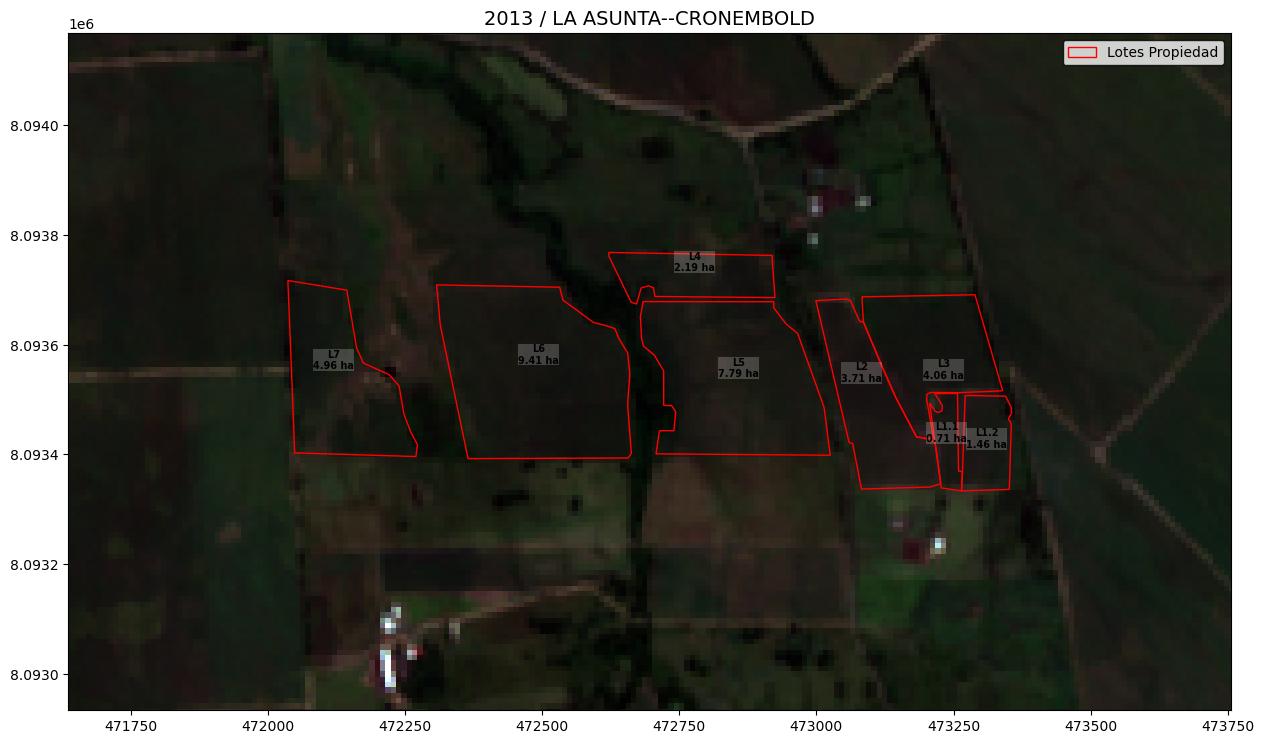

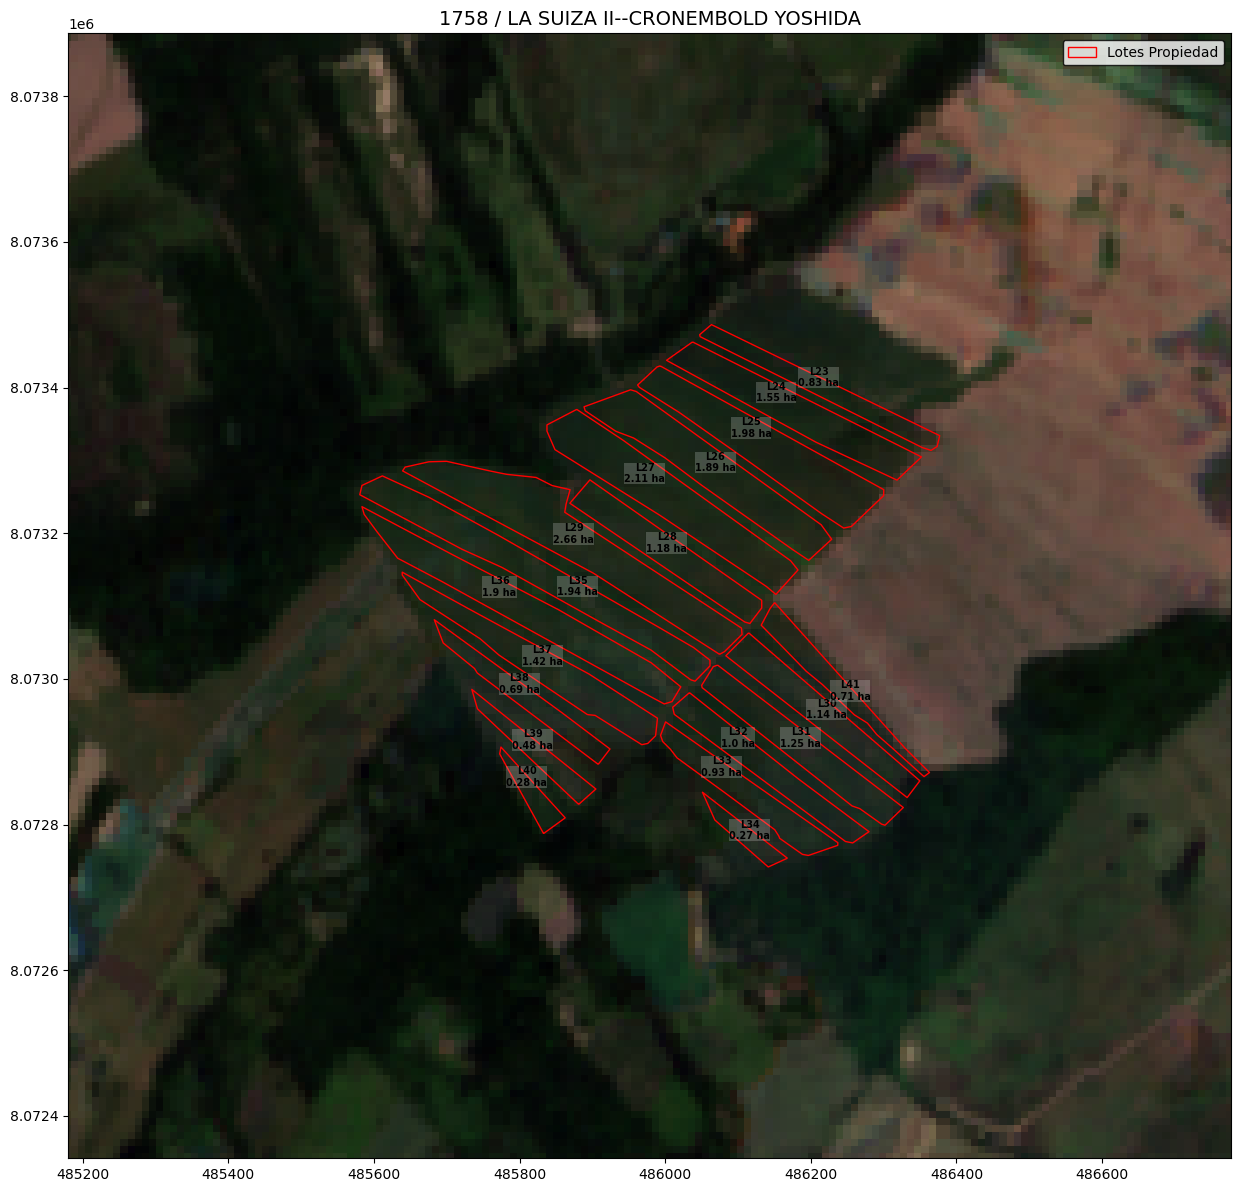

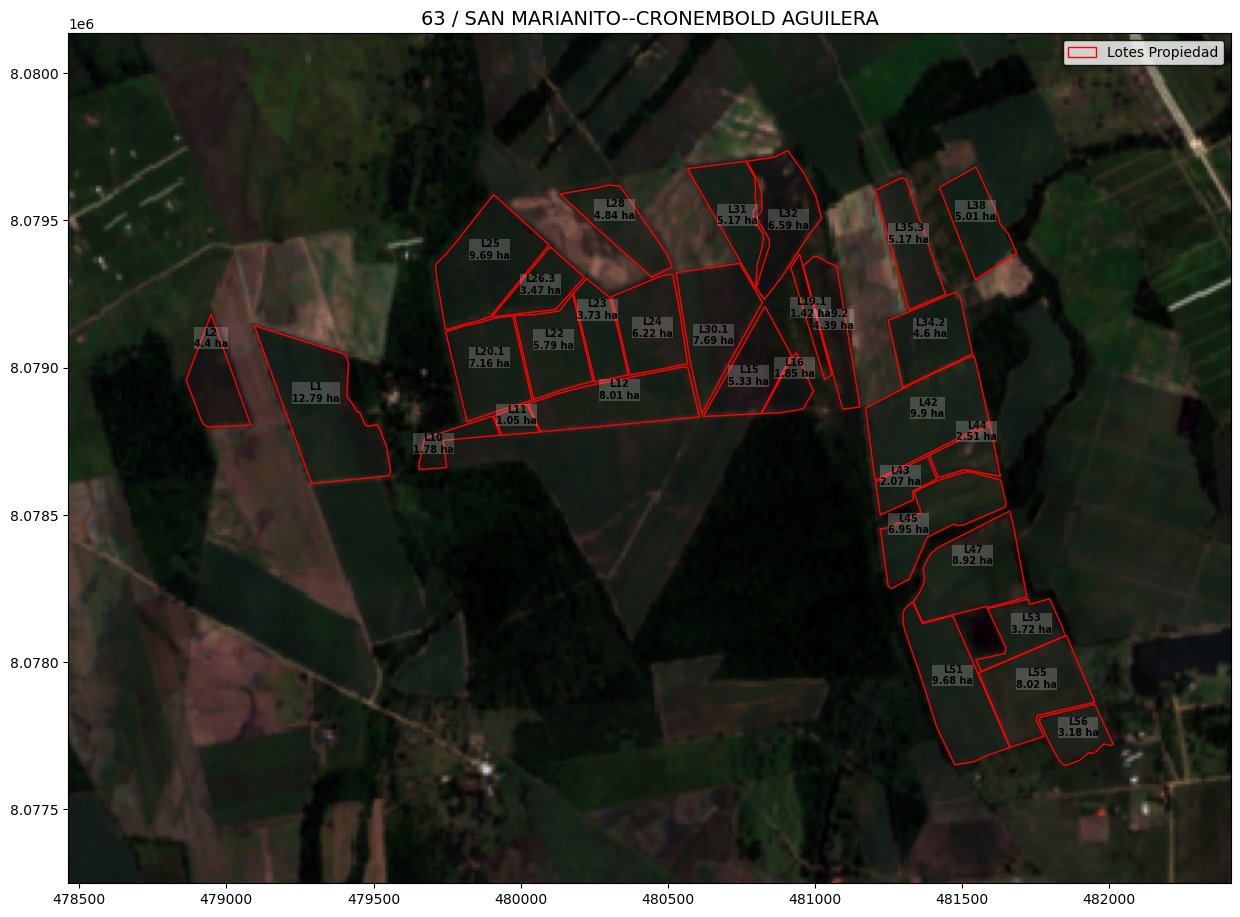

In [22]:
path_tif = RUTA_UNIDAD_ONE_DRIVE + r"\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - CATASTRO\RASTER\SENTINEL_2026-04-04_UTM.tif"
#path_tif = r"C:\Users\Usuario\Downloads\SENTINEL_2024-01-30_UTM.tif"
lista_path_planos = []
for cod_prop in lista_codigos_propiedad:
    propiedad = catastro_de_grupo[catastro_de_grupo['unidad_01'] == cod_prop]
    path_plano = generar_plano_pulv(propiedad, path_tif)
    lista_path_planos.append(path_plano)

In [23]:
lista_path_planos

['G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_1447_LA SUIZA--CRONEMBOLD YOSHIDA.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_2183_NARANJAL--CRONEMBOLD.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_1520_VILLA COPACABANA--CRONENBOLD.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_1521_DON LUIS & TAJIBO.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_220_SANTA BARBARA--CRONENBOLD ROBERTO.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_2013_LA ASUNTA--CRONEMBOLD.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_1758_LA SUIZA II--CRONEMBOLD YOSHIDA.jpg',
 'G:\\\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON\\planos/plano_INBA_63_SAN MARIANITO--CRONEMBOLD AGUILERA.jpg']

In [24]:
doc = DocxTemplate(PATH_COMPLETO+"/templates/tpl_informe_banco.docx")
in_line_qr = docxtpl.InlineImage(doc, image_descriptor=path_qr, width=Mm(30))
lista_propiedades_Inline = []
for plano in lista_path_planos:
    lista_propiedades_Inline.append(docxtpl.InlineImage(doc, image_descriptor=plano, width=Mm(150)))
context = {'insp' : datos_grupo, 'propiedades' : props_obj, 'planos' : lista_propiedades_Inline, 'total' : total, 'qr':in_line_qr}
doc.render(context)
file_name = str(codigo_delegado) + '_INBA_' + datos_grupo.fecha.replace('/', '-') + '_' + nombre_delegado
doc.save(PATH_COMPLETO + '/informes/_' + file_name + '.docx')